<a href="https://colab.research.google.com/github/sakram09/148/blob/main/cone_reflectivity_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries


In [1]:
!pip install opencv-python scikit-image scikit-learn matplotlib pandas


Upload Retinal Images


In [3]:
from google.colab import files
uploaded = files.upload()


Saving NORMAL RETINA.png to NORMAL RETINA.png


In [4]:
from google.colab import files
uploaded = files.upload()

Saving DIABETIC RETINA.jpg to DIABETIC RETINA (1).jpg


Import Required Libraries

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.feature import blob_log


Load and Display Image

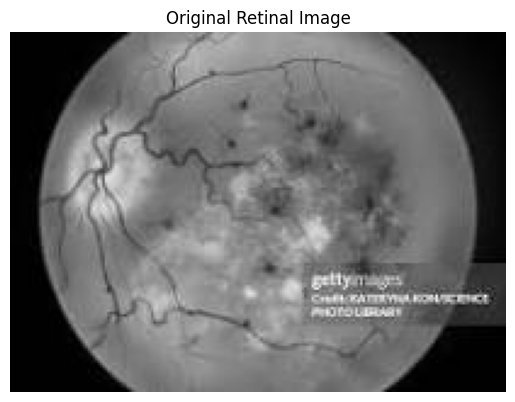

In [8]:
img = cv2.imread("DIABETIC RETINA.jpg", 0)

plt.imshow(img, cmap='gray')
plt.title("Original Retinal Image")
plt.axis("off")
plt.show()


Preprocess Image

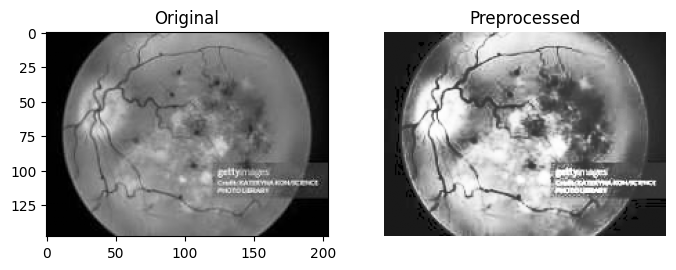

In [9]:
img_eq = cv2.equalizeHist(img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Preprocessed")
plt.axis("off")
plt.show()


Detect Cone Photoreceptors

In [10]:
blobs = blob_log(img_eq, min_sigma=2, max_sigma=5, threshold=0.02)
print("Total cones detected:", len(blobs))


Total cones detected: 212


Visualize Detected Cones

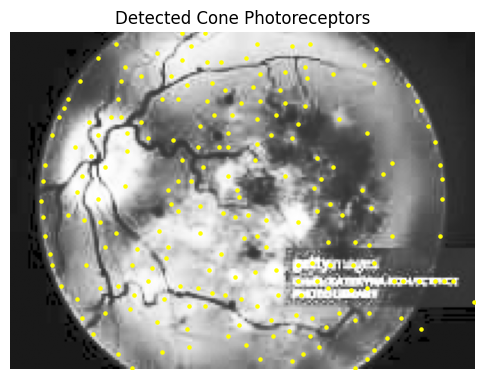

In [11]:
plt.figure(figsize=(6,6))
plt.imshow(img_eq, cmap='gray')

for y, x, r in blobs:
    plt.scatter(x, y, c='yellow', s=5)

plt.title("Detected Cone Photoreceptors")
plt.axis("off")
plt.show()


Measure Cone Reflectivity

In [12]:
reflectivity = []

for y, x, r in blobs:
    reflectivity.append(img_eq[int(y), int(x)])

reflectivity = np.array(reflectivity)


Identify Poorly Reflective Cones

In [13]:
threshold = np.percentile(reflectivity, 25)
poor_cones = reflectivity < threshold

print("Poorly reflective cones:", np.sum(poor_cones))


Poorly reflective cones: 51


Highlight Poorly Reflective Cones

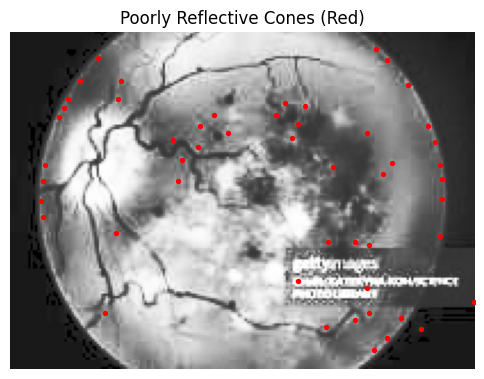

In [14]:
plt.figure(figsize=(6,6))
plt.imshow(img_eq, cmap='gray')

for i, (y, x, r) in enumerate(blobs):
    if poor_cones[i]:
        plt.scatter(x, y, c='red', s=8)

plt.title("Poorly Reflective Cones (Red)")
plt.axis("off")
plt.show()


Quantitative Metrics

In [15]:
percentage = (np.sum(poor_cones) / len(blobs)) * 100
print(f"Percentage of poorly reflective cones: {percentage:.2f}%")


Percentage of poorly reflective cones: 24.06%


Explainability Plot

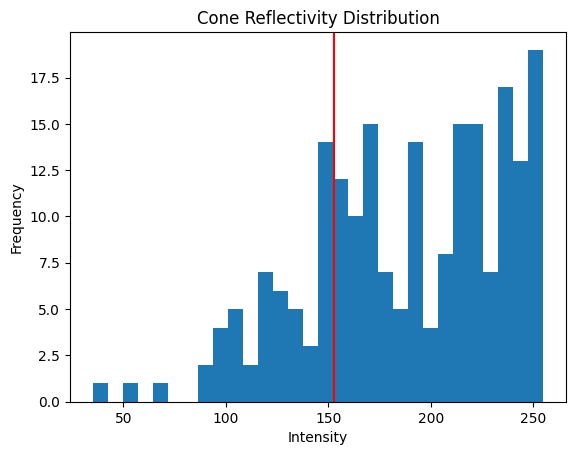

In [16]:
plt.hist(reflectivity, bins=30)
plt.axvline(threshold, color='red')
plt.title("Cone Reflectivity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()


Save Results to CSV

In [18]:
df = pd.DataFrame({
    "Reflectivity": reflectivity,
    "PoorCone": poor_cones
})

df.to_csv("cone_reflectivity_results.csv", index=False)

from google.colab import files
files.download("cone_reflectivity_results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Compare Normal vs Diabetic (Repeat Steps)

In [20]:
img = cv2.imread("NORMAL RETINA.png", 0)
